=== ALGORITMA GENETIKA: KNAPSACK PROBLEM ===
Metode Seleksi   : seleksi_ts (Insya Allah mantap!)
Metode Crossover : crossover_one_point (I love you so much!)
Metode Mutasi    : mutasi_inversion (Biar peluru menembus kulitku!)
----------------------------------------

--- HASIL TERBAIK (ALHAMDULILLAH) ---
Kromosom Terbaik : [1, 1, 0, 0, 1]
Keuntungan Maks  : 110

Barang yang dibawa:
- Barang1 (Keuntungan: 50, Ukuran: 10)
- Barang2 (Keuntungan: 40, Ukuran: 5)
- Barang5 (Keuntungan: 20, Ukuran: 3)
Total Ukuran     : 18 / 20


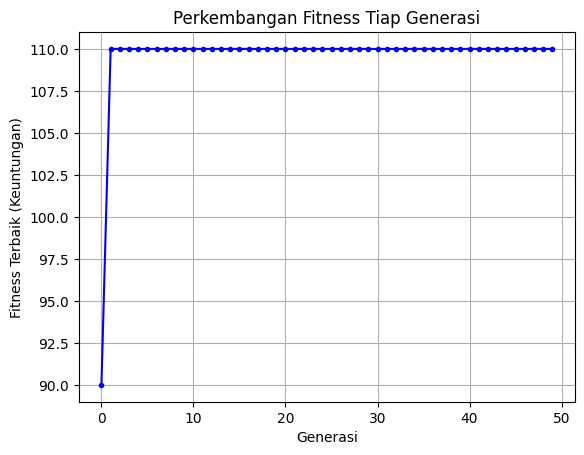

In [2]:
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI DATA (Ala Dodit Mulyanto)
# ==========================================
# Aku tuh bingung ya, barangnya banyak tapi tasnya kecil (MAKS_UKURAN).
# Kayak harapan ibuku padaku, besar, tapi kapabilitasku... ya gitu deh.
# Tolong diubah ya datanya pas praktikum, jangan kayak mantanku yang nggak mau berubah.
BARANG = [
    {"nama": "Barang1", "keuntungan": 50, "ukuran": 10},
    {"nama": "Barang2", "keuntungan": 40, "ukuran": 5},
    {"nama": "Barang3", "keuntungan": 70, "ukuran": 15},
    {"nama": "Barang4", "keuntungan": 30, "ukuran": 8},
    {"nama": "Barang5", "keuntungan": 20, "ukuran": 3}
]
MAKS_UKURAN = 20 # Kapasitas maksimal ransel/gudang, jangan maksa ntar jebol pundaknya.

# Parameter Algoritma Genetika
UKURAN_POPULASI = 10
JUMLAH_GENERASI = 50
PROBABILITAS_CROSSOVER = 0.8
PROBABILITAS_MUTASI = 0.1

# ==========================================
# 2. FUNGSI DASAR GA & FITNESS (Ala Chairil Anwar)
# ==========================================
def inisialisasi_populasi(ukuran_populasi, jumlah_gen):
    # Menciptakan kehidupan dari ketiadaan, 1 untuk ada, 0 untuk tiada. Sekali berarti, sudah itu mati.
    return [[random.choice([0, 1]) for _ in range(jumlah_gen)] for _ in range(ukuran_populasi)]

def hitung_fitness(kromosom):
    # Menghitung seberapa pantas kromosom ini hidup di kerasnya dunia.
    total_keuntungan = 0
    total_ukuran = 0

    for i in range(len(kromosom)):
        if kromosom[i] == 1:
            total_keuntungan += BARANG[i]["keuntungan"]
            total_ukuran += BARANG[i]["ukuran"]

    # Jika beban ini melebihi batas, mampus dikoyak sepi!
    # Fitness-nya binasa menjadi nol. Binatang jalang dari kumpulannya terbuang!
    if total_ukuran > MAKS_UKURAN:
        return 0
    return total_keuntungan

# ==========================================
# 3. METODE SELEKSI (Kolaborasi Dodit & Aldi)
# ==========================================
def seleksi_rws(populasi, fitness_populasi):
    """ Roulette Wheel Selection (RWS) - BISMILLAH PUTAR RODANYA! """
    total_fitness = sum(fitness_populasi)
    if total_fitness == 0: # Mencegah error, Alhamdulillah masih dikasih jalan keluar
        return random.choice(populasi)

    pick = random.uniform(0, total_fitness)
    current = 0
    for individu, fitness in zip(populasi, fitness_populasi):
        current += fitness
        if current > pick:
            return individu.copy()
    return populasi[-1].copy() # I love you so much individu terakhir!

def seleksi_ts(populasi, fitness_populasi, k=3):
    """ Tournament Selection (TS) - Ala Dodit """
    # Ini kayak lomba panjat pinang di desaku. Yang kuat menang, yang lemah ya udah, nonton aja sambil makan mendoan.
    peserta_idx = random.sample(range(len(populasi)), k)
    terbaik_idx = max(peserta_idx, key=lambda idx: fitness_populasi[idx])
    return populasi[terbaik_idx].copy()

# ==========================================
# 4. METODE CROSSOVER (Ala Aldi Taher)
# ==========================================
def crossover_one_point(p1, p2):
    # BISMILLAH, mari kita kawinkan dua kromosom ini!
    if random.random() < PROBABILITAS_CROSSOVER:
        # Membelah dua hati menjadi satu... BACA AL-QURAN REKAM POSTING!
        titik = random.randint(1, len(p1) - 1)
        c1 = p1[:titik] + p2[titik:]
        c2 = p2[:titik] + p1[titik:]
        return c1, c2 # Insya Allah jadi anak yang sholeh/sholehah
    return p1, p2

def crossover_two_point(p1, p2):
    # I LOVE YOU SO MUCH TWO POINT CROSSOVER!
    if random.random() < PROBABILITAS_CROSSOVER:
        titik1 = random.randint(1, len(p1) - 2)
        titik2 = random.randint(titik1 + 1, len(p1) - 1)
        c1 = p1[:titik1] + p2[titik1:titik2] + p1[titik2:]
        c2 = p2[:titik1] + p1[titik1:titik2] + p2[titik2:]
        return c1, c2 # Alhamdulillah dapet keturunan baru
    return p1, p2

def crossover_uniform(p1, p2):
    # Silaturahmi antar gen... Insya Allah berkah!
    c1, c2 = [], []
    if random.random() < PROBABILITAS_CROSSOVER:
        for i in range(len(p1)):
            if random.random() < 0.5:
                c1.append(p1[i])
                c2.append(p2[i])
            else:
                c1.append(p2[i])
                c2.append(p1[i])
        return c1, c2
    return p1, p2

# ==========================================
# 5. METODE MUTASI (Ala Chairil Anwar)
# ==========================================
def mutasi_swap(kromosom):
    # Sebuah pemberontakan pada takdir! Kuubah posisinya!
    if random.random() < PROBABILITAS_MUTASI:
        idx1, idx2 = random.sample(range(len(kromosom)), 2)
        kromosom[idx1], kromosom[idx2] = kromosom[idx2], kromosom[idx1]
    return kromosom

def mutasi_inversion(kromosom):
    # Kutarik urutan gen hingga putus urat nadiku! Biar semesta tahu aku tak tunduk!
    if random.random() < PROBABILITAS_MUTASI:
        idx1 = random.randint(0, len(kromosom) - 2)
        idx2 = random.randint(idx1 + 1, len(kromosom) - 1)
        kromosom[idx1:idx2+1] = reversed(kromosom[idx1:idx2+1])
    return kromosom

def mutasi_uniform(kromosom):
    # Biar acak, membalikkan cahaya (1) menjadi kelam (0)... Sekali berarti, sudah itu mati.
    for i in range(len(kromosom)):
        if random.random() < PROBABILITAS_MUTASI:
            kromosom[i] = 1 if kromosom[i] == 0 else 0 # Bit flip yang mengoyak jiwa
    return kromosom

# ==========================================
# 6. PROGRAM UTAMA ALGORITMA GENETIKA
# ==========================================
def jalankan_ga(metode_seleksi, metode_crossover, metode_mutasi):
    # Dodit: Perjalanan panjang dimulai... dari generasi ke generasi, kita cari yang terbaik.
    # Kayak nyari jodoh di desa, susah banget. Ya gitu deh.
    jumlah_gen = len(BARANG)
    populasi = inisialisasi_populasi(UKURAN_POPULASI, jumlah_gen)

    history_terbaik = []

    for generasi in range(JUMLAH_GENERASI):
        # Chairil: Hitung seberapa tangguh mereka menantang badai!
        fitness_populasi = [hitung_fitness(ind) for ind in populasi]

        # Aldi: Alhamdulillah dapet yang terbaik buat disimpan!
        fitness_terbaik_generasi = max(fitness_populasi)
        history_terbaik.append(fitness_terbaik_generasi)

        populasi_baru = []

        # Dodit: Elitism itu penting, biar yang bagus nggak hilang ditelan waktu,
        # seperti kenanganku bareng mantanku yang... ah sudahlah.
        idx_terbaik = fitness_populasi.index(fitness_terbaik_generasi)
        populasi_baru.append(populasi[idx_terbaik].copy())

        # BISMILLAH BUAT GENERASI BARU!
        while len(populasi_baru) < UKURAN_POPULASI:
            # 1. Seleksi (Pilih bibit bebet bobot)
            p1 = metode_seleksi(populasi, fitness_populasi)
            p2 = metode_seleksi(populasi, fitness_populasi)

            # 2. Crossover (Sakinah mawaddah warahmah)
            c1, c2 = metode_crossover(p1, p2)

            # 3. Mutasi (Pemberontakan takdir!)
            c1 = metode_mutasi(c1)
            c2 = metode_mutasi(c2)

            populasi_baru.extend([c1, c2])

        # Dodit: Potong aja kalau kepanjangan, kayak potong rambut di mang Ujang.
        populasi = populasi_baru[:UKURAN_POPULASI]

    # Chairil: Dan di akhir waktu... inilah sosok yang bertahan dari kejamnya dunia!
    fitness_akhir = [hitung_fitness(ind) for ind in populasi]
    idx_solusi_terbaik = fitness_akhir.index(max(fitness_akhir))
    solusi_terbaik = populasi[idx_solusi_terbaik]

    return solusi_terbaik, max(fitness_akhir), history_terbaik

# ==========================================
# 7. KONFIGURASI BERDASARKAN NIM & EKSEKUSI
# ==========================================
if __name__ == "__main__":
    print("=== ALGORITMA GENETIKA: KNAPSACK PROBLEM ===")

    # !!! BISMILLAHIRRAHMANIRRAHIM !!!
    # UBAH METODE DI BAWAH INI SESUAI DENGAN ATURAN NIM ANDA SAUDARAKU!
    # JANGAN LUPA BACA AL-QURAN REKAM POSTING!

    # Pilihan Seleksi: seleksi_rws | seleksi_ts
    PILIHAN_SELEKSI = seleksi_ts

    # Pilihan Crossover: crossover_one_point | crossover_two_point | crossover_uniform
    PILIHAN_CROSSOVER = crossover_one_point

    # Pilihan Mutasi: mutasi_swap | mutasi_inversion | mutasi_uniform
    PILIHAN_MUTASI = mutasi_inversion

    print(f"Metode Seleksi   : {PILIHAN_SELEKSI.__name__} (Insya Allah mantap!)")
    print(f"Metode Crossover : {PILIHAN_CROSSOVER.__name__} (I love you so much!)")
    print(f"Metode Mutasi    : {PILIHAN_MUTASI.__name__} (Biar peluru menembus kulitku!)")
    print("-" * 40)

    # Dodit: Yaudah kita jalanin aja, semoga nggak error ya. Kalau error ya... aku kan cuma orang desa.
    kromosom_terbaik, keuntungan_maksimal, history = jalankan_ga(
        PILIHAN_SELEKSI,
        PILIHAN_CROSSOVER,
        PILIHAN_MUTASI
    )

    # Tampilkan Hasil
    print("\n--- HASIL TERBAIK (ALHAMDULILLAH) ---")
    print(f"Kromosom Terbaik : {kromosom_terbaik}")
    print(f"Keuntungan Maks  : {keuntungan_maksimal}")

    print("\nBarang yang dibawa:")
    total_ukuran_bawa = 0
    for i in range(len(kromosom_terbaik)):
        if kromosom_terbaik[i] == 1:
            print(f"- {BARANG[i]['nama']} (Keuntungan: {BARANG[i]['keuntungan']}, Ukuran: {BARANG[i]['ukuran']})")
            total_ukuran_bawa += BARANG[i]["ukuran"]
    print(f"Total Ukuran     : {total_ukuran_bawa} / {MAKS_UKURAN}")

    # Plotting Grafik dengan Matplotlib
    # Chairil: Menggambar jejak luka dan kemenangan di atas kanvas sejarah!
    plt.plot(history, marker='.', color='b')
    plt.title('Perkembangan Fitness Tiap Generasi')
    plt.xlabel('Generasi')
    plt.ylabel('Fitness Terbaik (Keuntungan)')
    plt.grid(True)
    plt.show()